# Classification — Logistic Regression from Scratch

> *"You can't predict football, Bill."* — Sir Alex Ferguson
>
> Maybe not perfectly. But with a little probability theory, a sigmoid, and
> some gradient descent, we can do **a lot** better than a coin flip.

This notebook is the deep dive on **binary classification** that complements
our earlier work on regression. We start by asking why ordinary linear
regression breaks for 0/1 outcomes, build the logistic model from the
**Bernoulli** distribution, derive the **cross-entropy loss** as a maximum
likelihood estimator, and then *implement gradient descent from scratch* to
fit it. Finally, we look at what "good" actually means for a classifier:
confusion matrices, precision, recall, F1, ROC, and AUC.

Throughout we will be predicting whether **Arsenal wins a Premier League
match** — first from a single feature (expected goals difference), then
from two features so we can draw a decision boundary.


## Learning Objectives

After working through this notebook, you should be able to:

1. Explain **why linear regression fails for binary outcomes** and why we need
   a probability-bounded model instead.
2. Recognise the **Bernoulli** and **Binomial** distributions as the natural
   model for a 0/1 outcome and an aggregated count of successes.
3. Move fluently between **probability**, **odds**, and **log-odds (logit)**,
   and recover the **sigmoid** by inverting the logit.
4. Derive the **binary cross-entropy loss** as the negative log-likelihood of
   the Bernoulli model.
5. Derive the gradient of cross-entropy and recognise the elegant form
   $\nabla_w L = X^\top(\hat{p} - y)$.
6. **Implement vanilla batch gradient descent from scratch** for logistic
   regression and verify your weights match `statsmodels.Logit`.
7. Visualise the **decision boundary** of a fitted classifier in 2D.
8. Read a **confusion matrix** and compute **precision**, **recall**,
   **F1-score**, **ROC curve**, and **AUC**.
9. Explain when **accuracy is misleading** and how to pick a useful
   classification threshold.
10. Sketch how the binary case generalises to **multiclass classification**
    via the softmax function.


## Setup

A standard scientific stack. We pin the seed so every plot in this notebook
is reproducible — change the seed at home and rerun to see how the story
holds up under fresh randomness.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_curve,
    auc,
)

rng = np.random.default_rng(42)
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## 1. Why not linear regression for 0/1 outcomes?

Imagine you're an Arsenal data analyst. For each Premier League match this
season you have:

- $x$ = **expected goals difference** (Arsenal's xG minus the opponent's xG).
  Positive means Arsenal generated better chances; negative means the
  opponent did.
- $y$ = **outcome** — 1 if Arsenal won, 0 otherwise.

Let's simulate one season of matches and try the obvious thing first:
fit a straight line.

In [2]:
# Simulate one season of matches
n_matches = 80
xg_diff = rng.normal(0.3, 1.2, size=n_matches)            # xG advantage per match

# True data-generating process — wins follow a logistic relationship
true_w, true_b = 1.8, 0.4
true_p = 1 / (1 + np.exp(-(true_w * xg_diff + true_b)))
y = rng.binomial(1, true_p)

matches = pd.DataFrame({"xg_diff": xg_diff, "won": y})
matches.head()


,xg_diff,won
0,0.665660,1
1,-0.947981,0
2,1.200541,1
3,1.428678,1
4,-2.041242,0


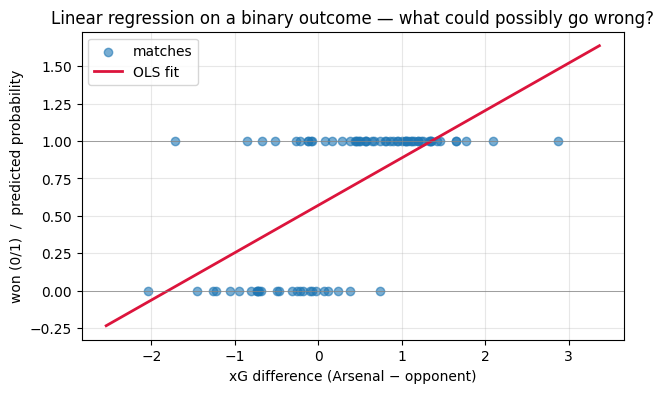

In [3]:
# Fit OLS — pretend the binary outcome is just a real number
X_ols = sm.add_constant(matches["xg_diff"])
ols_fit = sm.OLS(matches["won"], X_ols).fit()

x_grid = np.linspace(matches["xg_diff"].min() - 0.5, matches["xg_diff"].max() + 0.5, 200)
ols_pred = ols_fit.params["const"] + ols_fit.params["xg_diff"] * x_grid

fig, ax = plt.subplots()
ax.scatter(matches["xg_diff"], matches["won"], alpha=0.6, label="matches")
ax.plot(x_grid, ols_pred, color="crimson", lw=2, label="OLS fit")
ax.axhline(0, color="grey", lw=0.5)
ax.axhline(1, color="grey", lw=0.5)
ax.set_xlabel("xG difference (Arsenal − opponent)")
ax.set_ylabel("won (0/1)  /  predicted probability")
ax.set_title("Linear regression on a binary outcome — what could possibly go wrong?")
ax.legend()
plt.show()


Three problems jump out:

1. **Predictions escape $[0, 1]$.** For matches with a very large positive xG
   difference the fitted line predicts probabilities **above 1**; for very
   negative xG it predicts **below 0**. Probabilities don't do that.
2. **Linearity is wrong.** Going from xG diff $-2 \to -1$ probably matters a
   lot more for win probability than going from $+3 \to +4$ (a thrashing is
   still a thrashing). A straight line treats them as equal.
3. **Residuals are weird.** OLS assumes normal residuals. With a 0/1
   response, the residuals can only take two values for any given $x$, so
   the Gaussian assumption is badly violated.

We need a model that produces a number between 0 and 1 *by construction*.
That's where the **sigmoid** comes in — but to motivate it properly we first
need a quick refresher on the right probability distribution for a binary
outcome.


## 2. Bernoulli & Binomial — a quick refresher

A **Bernoulli** random variable models a single yes/no event:

$$ Y \sim \text{Bernoulli}(p) \quad\Longleftrightarrow\quad P(Y = 1) = p,\ \ P(Y = 0) = 1 - p. $$

Mean $\mathbb{E}[Y] = p$, variance $\text{Var}(Y) = p(1-p)$.

A **Binomial** is what you get if you sum $n$ independent Bernoullis with the
same $p$ — for example, "how many of Arsenal's next 38 matches do they win?"

$$ S = \sum_{i=1}^{n} Y_i \sim \text{Binomial}(n, p), \qquad P(S=k) = \binom{n}{k} p^k (1-p)^{n-k}. $$

For *modelling a single match outcome*, the Bernoulli is exactly the right
distribution. The whole task of logistic regression is: **let $p$ depend on
features $x$**, and then estimate that dependence from data.


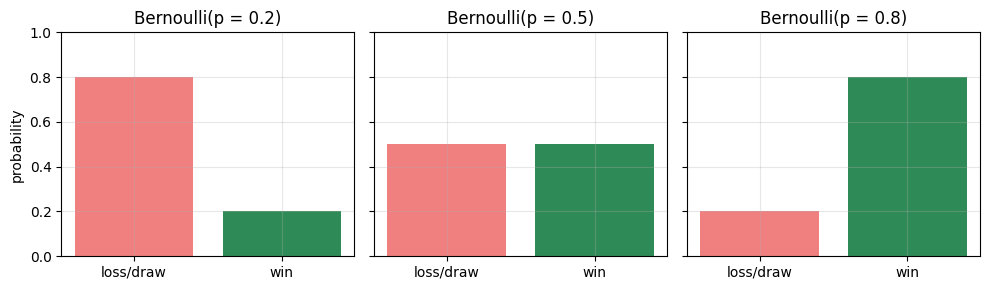

In [4]:
# Visualise: how the Bernoulli mass shifts as p changes
ps = [0.2, 0.5, 0.8]
fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharey=True)
for ax, p in zip(axes, ps):
    ax.bar([0, 1], [1 - p, p], color=["lightcoral", "seagreen"])
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["loss/draw", "win"])
    ax.set_ylim(0, 1)
    ax.set_title(f"Bernoulli(p = {p})")
axes[0].set_ylabel("probability")
plt.tight_layout()
plt.show()


## 3. From probability to log-odds (and back)

We want a model that maps a real-valued linear combination
$z = w x + b$ — which can be anything in $(-\infty, \infty)$ — to a
probability in $(0, 1)$. The trick is to do it in two steps via the
**odds** and the **log-odds**.

**Odds** are the ratio of "yes" to "no" probability:

$$ \text{odds}(p) = \frac{p}{1 - p} \in (0, \infty). $$

**Log-odds** (or **logit**) take the log to stretch the odds onto the whole
real line:

$$ \text{logit}(p) = \log \frac{p}{1 - p} \in (-\infty, \infty). $$

Now we can comfortably *equate* the logit to a linear function of features:

$$ \log \frac{p}{1 - p} = w x + b. $$

Inverting this gives back $p$ — and the inverse is the **sigmoid** (also
called the *logistic function*):

$$ p = \sigma(z) = \frac{1}{1 + e^{-z}}, \qquad z = wx + b. $$

The sigmoid is the bridge between unbounded "score" $z$ and bounded
probability $p$.

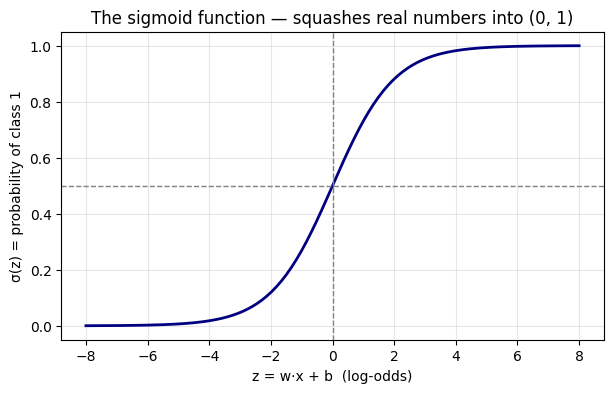

In [5]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

z = np.linspace(-8, 8, 200)
fig, ax = plt.subplots()
ax.plot(z, sigmoid(z), color="navy", lw=2)
ax.axhline(0.5, color="grey", ls="--", lw=1)
ax.axvline(0, color="grey", ls="--", lw=1)
ax.set_xlabel("z = w·x + b  (log-odds)")
ax.set_ylabel("σ(z) = probability of class 1")
ax.set_title("The sigmoid function — squashes real numbers into (0, 1)")
plt.show()


Three things to remember:

- $\sigma(0) = 0.5$ — the decision boundary is at $z = 0$.
- $\sigma(z) \to 1$ as $z \to +\infty$ and $\sigma(z) \to 0$ as $z \to -\infty$.
- $\sigma'(z) = \sigma(z)\,(1 - \sigma(z))$. We will use this when we derive
  the gradient — it is what makes the algebra collapse so neatly.


## 4. The logistic regression model

Putting it all together, **logistic regression** is the model

$$ P(y = 1 \mid x) = \sigma(w^\top x + b). $$

Equivalently:

$$ \log \frac{P(y=1\mid x)}{P(y=0\mid x)} = w^\top x + b. $$

Two language points worth nailing down:

- The **score** $z = w^\top x + b$ is the *log-odds* of class 1.
- The **decision boundary** is the set of $x$ where $z = 0$ (equivalently
  $P(y=1\mid x) = 0.5$). For one feature, that's a single threshold; for
  two features, it's a straight line; for $d$ features, a $(d-1)$-dim
  hyperplane.

Despite being called "regression", this is a **classification** model — the
output is a probability, and we usually convert it to a 0/1 prediction by
thresholding at 0.5 (though we'll see later this threshold is a knob you
can tune).


## 5. Where does the loss come from? Maximum likelihood

We have a parametric model $P(y=1\mid x) = \sigma(w^\top x + b)$. To fit it
to data we need a *loss function* — a single number that says "how badly is
the model doing on this dataset?". For logistic regression, that loss is
**not** chosen arbitrarily. It falls out of **maximum likelihood
estimation** of the Bernoulli model.

Suppose we have $n$ matches $(x_i, y_i)$ with $y_i \in \{0, 1\}$, and write
$\hat{p}_i = \sigma(w^\top x_i + b)$. Treating each match as an independent
Bernoulli trial, the **likelihood** of the whole dataset is

$$ \mathcal{L}(w, b) = \prod_{i=1}^{n} \hat{p}_i^{\,y_i} (1 - \hat{p}_i)^{1 - y_i}. $$

That clever-looking product is just "use $\hat{p}_i$ when $y_i = 1$, use
$1 - \hat{p}_i$ when $y_i = 0$" written compactly. Taking $-\log$ to turn
the product into a sum (and a maximisation into a minimisation) gives the
**negative log-likelihood**:

$$ -\log \mathcal{L}(w, b) = -\sum_{i=1}^{n}\Big[y_i \log \hat{p}_i + (1 - y_i)\log(1 - \hat{p}_i)\Big]. $$

This expression has a name in machine learning: **binary cross-entropy
loss**. So the "loss function" of logistic regression is not an arbitrary
choice — it is *exactly* the negative log-likelihood of the Bernoulli model.

> **The bridge:** Bernoulli distribution + maximum likelihood = binary
> cross-entropy loss. This is *the* connection the notebook is built around.

Conventionally we average over $n$ to get a per-sample loss:

$$ L(w, b) = -\frac{1}{n}\sum_{i=1}^{n}\Big[y_i \log \hat{p}_i + (1 - y_i)\log(1 - \hat{p}_i)\Big]. $$


## 6. The gradient of cross-entropy

To run gradient descent we need $\nabla_w L$. Using $\hat{p}_i = \sigma(z_i)$
with $z_i = w^\top x_i + b$, and the identity
$\sigma'(z) = \sigma(z)(1 - \sigma(z))$, the chain rule gives (after a small
amount of algebra that *every* ML student should do once by hand):

$$ \frac{\partial L}{\partial w_j} = \frac{1}{n}\sum_{i=1}^{n}(\hat{p}_i - y_i)\,x_{ij}. $$

In matrix form, with $X \in \mathbb{R}^{n \times d}$ stacking the features:

$$ \boxed{\ \nabla_w L = \frac{1}{n} X^\top (\hat{p} - y)\ } $$

That is the punchline. The gradient is just **"predicted minus actual",
weighted by the inputs** — exactly the same shape as the gradient of squared
error in linear regression. Different probabilistic story, same
algorithmic move.

The bias gradient is the analogous scalar:

$$ \frac{\partial L}{\partial b} = \frac{1}{n}\sum_{i=1}^{n}(\hat{p}_i - y_i). $$


## 7. Gradient descent from scratch

We now turn the maths into code. The recipe is short:

1. Start with $w = 0$, $b = 0$.
2. Compute $\hat{p} = \sigma(Xw + b)$.
3. Compute the gradient $g_w = \tfrac{1}{n} X^\top (\hat{p} - y)$ and
   $g_b = \tfrac{1}{n} \mathbf{1}^\top (\hat{p} - y)$.
4. Step: $w \gets w - \eta\, g_w$, $b \gets b - \eta\, g_b$.
5. Repeat for many epochs and watch the loss go down.

We'll use the single-feature Arsenal data we already simulated, plus a
small numerical-stability trick: we clip $\hat{p}$ away from exactly 0 and
1 before taking logs.

In [6]:
def bce_loss(y, p, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))


def fit_logistic_gd(X, y, lr=0.1, n_epochs=2000):
    # Vanilla batch gradient descent for binary logistic regression.
    n, d = X.shape
    w = np.zeros(d)
    b = 0.0
    losses = []
    for _ in range(n_epochs):
        z = X @ w + b
        p = sigmoid(z)
        # gradients
        g_w = (X.T @ (p - y)) / n
        g_b = np.mean(p - y)
        # update
        w -= lr * g_w
        b -= lr * g_b
        losses.append(bce_loss(y, p))
    return w, b, np.array(losses)


X1 = matches[["xg_diff"]].to_numpy()      # shape (n, 1)
y_arr = matches["won"].to_numpy()

w_hat, b_hat, losses = fit_logistic_gd(X1, y_arr, lr=0.2, n_epochs=4000)
print(f"learned weight w  = {w_hat[0]: .4f}    (true {true_w})")
print(f"learned bias   b  = {b_hat: .4f}    (true {true_b})")
print(f"final loss       = {losses[-1]:.4f}")


learned weight w  =  2.3022    (true 1.8)
learned bias   b  =  0.4690    (true 0.4)
final loss       = 0.3918


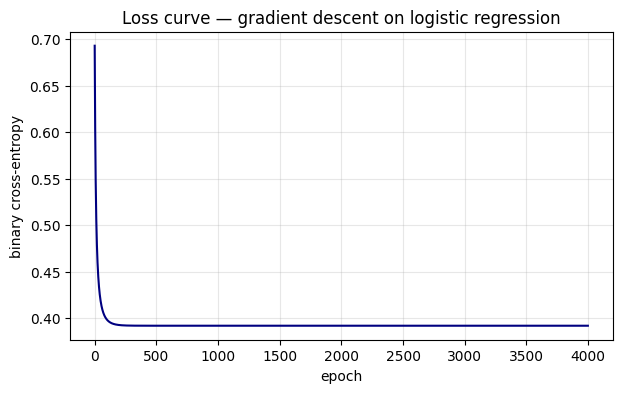

In [7]:
# Loss curve — the classic monotone descent
fig, ax = plt.subplots()
ax.plot(losses, color="navy")
ax.set_xlabel("epoch")
ax.set_ylabel("binary cross-entropy")
ax.set_title("Loss curve — gradient descent on logistic regression")
plt.show()


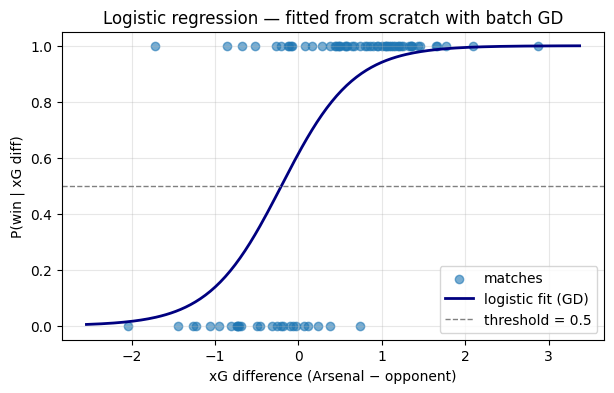

In [8]:
# Plot the fitted sigmoid against the data
x_grid = np.linspace(matches["xg_diff"].min() - 0.5, matches["xg_diff"].max() + 0.5, 200)
p_grid = sigmoid(w_hat[0] * x_grid + b_hat)

fig, ax = plt.subplots()
ax.scatter(matches["xg_diff"], matches["won"], alpha=0.6, label="matches")
ax.plot(x_grid, p_grid, color="navy", lw=2, label="logistic fit (GD)")
ax.axhline(0.5, color="grey", ls="--", lw=1, label="threshold = 0.5")
ax.set_xlabel("xG difference (Arsenal − opponent)")
ax.set_ylabel("P(win | xG diff)")
ax.set_title("Logistic regression — fitted from scratch with batch GD")
ax.legend()
plt.show()


## 8. Sanity check — compare with `statsmodels.Logit`

A from-scratch implementation is only useful if we can verify it against a
trusted library. `statsmodels.Logit` fits the same model using a
Newton-Raphson solver, so its coefficients should match ours within a
small tolerance.

In [9]:
X_sm = sm.add_constant(matches["xg_diff"])
sm_logit = sm.Logit(matches["won"], X_sm).fit(disp=False)
print(sm_logit.summary().tables[1])

print()
print(f"statsmodels  intercept = {sm_logit.params['const']: .4f},  slope = {sm_logit.params['xg_diff']: .4f}")
print(f"our GD       intercept = {b_hat: .4f},  slope = {w_hat[0]: .4f}")


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4690      0.317      1.482      0.138      -0.151       1.089
xg_diff        2.3022      0.520      4.428      0.000       1.283       3.321

statsmodels  intercept =  0.4690,  slope =  2.3022
our GD       intercept =  0.4690,  slope =  2.3022


The two sets of coefficients agree to a couple of decimal places — a small
gap remains because batch GD with a fixed learning rate hasn't fully
converged, while `statsmodels` uses a second-order solver. Crank the
epochs or the learning rate up and they'll match more tightly.

This is exactly the same comparison we did for Ridge regression in the
*Regularization* notebook — implementing the algorithm by hand and then
checking against a reference is one of the best habits you can build as a
data scientist.

## 9. Two features → a decision boundary you can see

With one feature the "boundary" is just a threshold on the x-axis. With
**two features** we can finally *see* what the classifier is doing — the
boundary becomes a straight line in feature space.

We'll add a second feature, **possession percentage**, and refit.

In [10]:
# Add possession as a second feature
possession = rng.normal(55, 8, size=n_matches)        # Arsenal possession %

# Underlying truth: both features matter
z_true = 1.5 * xg_diff + 0.07 * (possession - 50) + 0.2
p_true = sigmoid(z_true)
y2 = rng.binomial(1, p_true)

X2 = np.column_stack([xg_diff, possession])
w2, b2, losses2 = fit_logistic_gd(X2, y2, lr=0.05, n_epochs=8000)
print(f"weights = {w2},   bias = {b2:.3f}")


weights = [15.04475554 -0.15072324],   bias = -8.003


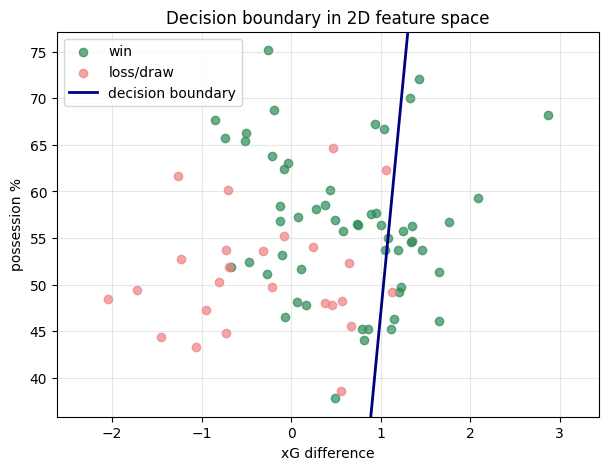

In [11]:
# Plot points, colour by class, overlay decision boundary
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(xg_diff[y2 == 1], possession[y2 == 1], color="seagreen", label="win", alpha=0.7)
ax.scatter(xg_diff[y2 == 0], possession[y2 == 0], color="lightcoral", label="loss/draw", alpha=0.7)

# Decision boundary: w1*x1 + w2*x2 + b = 0  ⇒  x2 = -(w1*x1 + b) / w2
x1_line = np.linspace(xg_diff.min() - 0.3, xg_diff.max() + 0.3, 100)
x2_line = -(w2[0] * x1_line + b2) / w2[1]
ax.plot(x1_line, x2_line, color="navy", lw=2, label="decision boundary")

ax.set_xlabel("xG difference")
ax.set_ylabel("possession %")
ax.set_title("Decision boundary in 2D feature space")
ax.legend()
ax.set_ylim(possession.min() - 2, possession.max() + 2)
plt.show()


Logistic regression draws a **linear** boundary. Points above the line are
predicted as "win", points below as "loss/draw". The further a point is from
the line, the more confident the model is in its prediction (because the
log-odds $z$ is further from zero). That's why logistic regression is
sometimes called a *linear classifier*: even though the sigmoid is curved,
the decision surface is flat.


## 10. Classification metrics — beyond accuracy

Once we have predicted probabilities $\hat{p}_i$, we can convert them to
predicted classes by thresholding (default: $\hat{y} = 1$ if $\hat{p} \ge
0.5$). But how do we measure how good the predictions are?

The **confusion matrix** tabulates predictions against truth:

|              | Predicted 0 | Predicted 1 |
|--------------|-------------|-------------|
| **Actual 0** | TN          | FP          |
| **Actual 1** | FN          | TP          |

From it we get four standard metrics:

- **Accuracy** $= \dfrac{TP + TN}{TP + TN + FP + FN}$ — overall hit rate.
- **Precision** $= \dfrac{TP}{TP + FP}$ — *of the matches I predicted Arsenal would win, how many did they actually win?*
- **Recall** (sensitivity) $= \dfrac{TP}{TP + FN}$ — *of the matches Arsenal actually won, how many did I catch?*
- **F1-score** $= \dfrac{2 \cdot \text{prec} \cdot \text{rec}}{\text{prec} + \text{rec}}$ — harmonic mean; balances the two.


In [12]:
# Predictions on the 2-feature model at the default threshold of 0.5
p_hat = sigmoid(X2 @ w2 + b2)
y_pred = (p_hat >= 0.5).astype(int)

cm = confusion_matrix(y2, y_pred)
print("Confusion matrix:")
print(pd.DataFrame(cm,
                   index=["actual loss/draw", "actual win"],
                   columns=["predicted loss/draw", "predicted win"]))

print()
print(f"accuracy  = {accuracy_score(y2, y_pred):.3f}")
print(f"precision = {precision_score(y2, y_pred):.3f}")
print(f"recall    = {recall_score(y2, y_pred):.3f}")
print(f"F1        = {f1_score(y2, y_pred):.3f}")


Confusion matrix:
                  predicted loss/draw  predicted win
actual loss/draw                   24              1
actual win                         38             17

accuracy  = 0.512
precision = 0.944
recall    = 0.309
F1        = 0.466


**When accuracy lies.** Imagine a season where Arsenal win 95% of their
matches (a lovely fantasy). A model that *always* predicts "win" would have
95% accuracy without learning anything — it would have **zero recall on
losses** and would never warn you about an upset. This is the classic
**class-imbalance trap**.

For imbalanced problems, look at precision, recall, F1, and the ROC curve
*together*, not accuracy alone.


## 11. Threshold tuning, ROC, and AUC

The 0.5 threshold is a *default*, not a law. Lowering it makes the model
more eager to predict "win" — recall goes up, precision goes down. Raising
it does the opposite. The right threshold depends on the cost of false
positives versus false negatives in your application.

The **ROC curve** plots **true positive rate** (recall) against **false
positive rate** as the threshold sweeps from 1 down to 0. The **AUC** (area
under the ROC curve) summarises the curve as a single number: 1.0 is a
perfect classifier, 0.5 is random guessing.


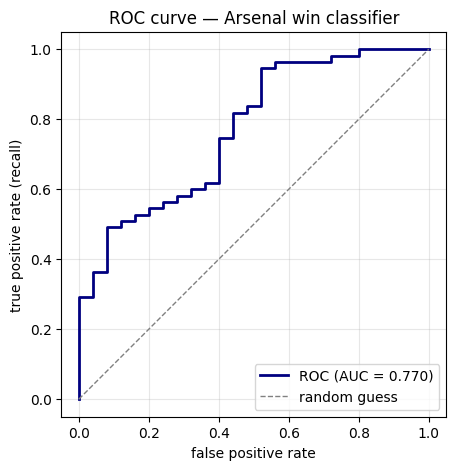

In [13]:
fpr, tpr, thresholds = roc_curve(y2, p_hat)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(fpr, tpr, color="navy", lw=2, label=f"ROC (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], color="grey", ls="--", lw=1, label="random guess")
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate (recall)")
ax.set_title("ROC curve — Arsenal win classifier")
ax.legend(loc="lower right")
ax.set_aspect("equal")
plt.show()


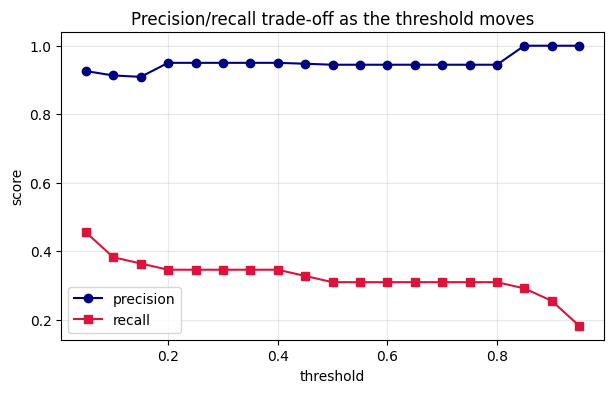

In [14]:
# How precision & recall trade off as threshold changes
ts = np.linspace(0.05, 0.95, 19)
prec_list, rec_list = [], []
for t in ts:
    yt = (p_hat >= t).astype(int)
    prec_list.append(precision_score(y2, yt, zero_division=0))
    rec_list.append(recall_score(y2, yt, zero_division=0))

fig, ax = plt.subplots()
ax.plot(ts, prec_list, marker="o", label="precision", color="navy")
ax.plot(ts, rec_list, marker="s", label="recall", color="crimson")
ax.set_xlabel("threshold")
ax.set_ylabel("score")
ax.set_title("Precision/recall trade-off as the threshold moves")
ax.legend()
plt.show()


A useful rule of thumb: the **F1-score** peaks at a threshold that balances
precision and recall, so if you have no domain-specific cost preference,
picking the threshold that maximises F1 on a validation set is a sensible
default.

> **Side note — regularised logistic regression.** If your model overfits
> (lots of features, few samples), you can add an $L_2$ or $L_1$ penalty
> to the cross-entropy loss in exactly the same way we did for Ridge and
> Lasso in the *Regularization* notebook. The gradient picks up an extra
> $+\lambda w$ term and everything else stays the same.


## 12. Beyond binary — a softmax teaser

What if we want to predict three or more classes (win / draw / loss
properly, instead of collapsing draws into "not a win")? The Bernoulli
generalises to the **categorical** distribution, and the sigmoid
generalises to the **softmax**:

$$ P(y = k \mid x) = \frac{e^{w_k^\top x + b_k}}{\sum_{j=1}^{K} e^{w_j^\top x + b_j}}. $$

Each class gets its own weight vector $w_k$. The loss generalises in the
obvious way to **categorical cross-entropy**:

$$ L = -\frac{1}{n}\sum_{i=1}^{n} \sum_{k=1}^{K} \mathbb{1}[y_i = k]\, \log P(y_i = k \mid x_i). $$

The gradient still has the beautiful form **"predicted minus actual"** —
where "actual" is now a one-hot vector and "predicted" is the softmax
probability vector. Everything you learned in the binary case carries
over.

In practice you can do multiclass logistic regression with a single line:


In [15]:
from sklearn.linear_model import LogisticRegression

# Simulate a 3-class outcome: 0 = loss, 1 = draw, 2 = win
z_w = 1.4 * xg_diff + 0.06 * (possession - 50)
z_l = -1.4 * xg_diff - 0.06 * (possession - 50)
exps = np.exp(np.column_stack([z_l, np.zeros(n_matches), z_w]))
probs = exps / exps.sum(axis=1, keepdims=True)
y3 = np.array([rng.choice(3, p=p) for p in probs])

clf = LogisticRegression(multi_class="multinomial", max_iter=1000)
clf.fit(X2, y3)
print("multinomial coefficients shape:", clf.coef_.shape)   # (n_classes, n_features)
print("training accuracy:", clf.score(X2, y3))


multinomial coefficients shape: (3, 2)
training accuracy: 0.75


/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


## 13. Key takeaways

- **Binary outcomes need a probability model**, not a straight line.
  Linear regression on 0/1 data produces nonsense outside $[0, 1]$ and
  violates its own assumptions.
- The right model is the **Bernoulli**, with its parameter $p$ allowed to
  depend on features through the **sigmoid** of a linear score:
  $P(y=1\mid x) = \sigma(w^\top x + b)$.
- The **loss isn't arbitrary** — binary cross-entropy is *exactly* the
  negative log-likelihood of the Bernoulli model.
- The gradient of cross-entropy collapses to the elegant
  **$X^\top(\hat{p} - y) / n$** — "predicted minus actual", weighted by
  inputs. Same algorithmic shape as the gradient of squared error.
- A **from-scratch GD implementation** can be checked against
  `statsmodels.Logit` — they should agree on the coefficients (up to
  convergence tolerance).
- The decision boundary of logistic regression is **linear**; that's why
  it's called a linear classifier, even though the sigmoid is curved.
- **Accuracy alone is misleading** on imbalanced data. Always look at
  precision, recall, F1, and the ROC/AUC together.
- The **threshold** of 0.5 is a default, not a law — sweep it and pick the
  operating point your application actually needs.
- **Multiclass classification** is the same idea with the softmax replacing
  the sigmoid and categorical cross-entropy replacing binary cross-entropy.


## 14. Practice exercises

1. **Hand derivation.** Starting from $L = -\frac{1}{n}\sum [y\log\sigma(z) +
   (1-y)\log(1-\sigma(z))]$, show by chain rule that $\partial L / \partial w_j
   = \frac{1}{n}\sum (\sigma(z_i) - y_i)\, x_{ij}$. Use the identity
   $\sigma'(z) = \sigma(z)(1 - \sigma(z))$.
2. **Threshold tuning.** Using the predicted probabilities `p_hat` from the
   2-feature model, find the threshold that maximises F1-score on this
   dataset. Plot F1 as a function of threshold.
3. **Different learning rate.** Re-run `fit_logistic_gd` with `lr=0.001`,
   `lr=0.05`, and `lr=2.0`. Which converges fastest? Which diverges?
4. **Add a feature.** Simulate a third feature ("days of rest before the
   match") that has *no* relationship to the outcome. Refit the model and
   inspect the learned weight — what would you expect, and what do you see?
5. **Imbalanced classes.** Simulate a season where the win rate is 90%.
   Fit the model and report accuracy, precision, recall, and F1. Then try
   the trivial classifier "always predict win" and compare. What does this
   tell you about accuracy as a metric?
6. **Connect to GLM.** Refit the single-feature model using
   `sm.GLM(y, X, family=sm.families.Binomial())` instead of `sm.Logit`.
   Confirm the coefficients are identical and explain why.
